In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/charithapendyala/shl-grammar-transcript/train_with_transcripts.csv
/kaggle/input/datasets/charithapendyala/shl-grammar-transcript/test_with_transcripts.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Datase

In [3]:
import os
import re
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# =========================================================
# PATHS
# =========================================================

DATA_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

TRAIN_AUDIO_DIR = os.path.join(DATA_DIR, "train")
TEST_AUDIO_DIR = os.path.join(DATA_DIR, "test")

# Cached Whisper transcripts
TRAIN_TRANSCRIPT_PATH = (
    "/kaggle/input/datasets/charithapendyala/"
    "shl-grammar-transcript/train_with_transcripts.csv"
)

TEST_TRANSCRIPT_PATH = (
    "/kaggle/input/datasets/charithapendyala/"
    "shl-grammar-transcript/test_with_transcripts.csv"
)

# =========================================================
# LOAD TRANSCRIPTS
# =========================================================

train_df = pd.read_csv(TRAIN_TRANSCRIPT_PATH)
test_df = pd.read_csv(TEST_TRANSCRIPT_PATH)

# 8 missing training transcripts
train_df["transcript"] = train_df["transcript"].fillna("")
test_df["transcript"] = test_df["transcript"].fillna("")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("Train columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

print("Missing train transcripts:",
      train_df["transcript"].isna().sum())

print("Missing test transcripts:",
      test_df["transcript"].isna().sum())

print("\nTrain audio files:",
      len(os.listdir(TRAIN_AUDIO_DIR)))

print("Test audio files:",
      len(os.listdir(TEST_AUDIO_DIR)))

Train shape: (769, 3)
Test shape : (216, 3)
Train columns: ['filename', 'label', 'transcript']
Test columns : ['filename', 'label', 'transcript']
Missing train transcripts: 0
Missing test transcripts: 0

Train audio files: 769
Test audio files: 216


In [4]:
FILLER_WORDS = {
    "uh", "um", "hmm", "huh", "erm", "ah",
    "uhh", "umm", "actually", "basically",
    "like", "you know"
}


def extract_linguistic_features(text):

    text = str(text).strip()

    # Words
    words = re.findall(
        r"\b[a-zA-Z']+\b",
        text.lower()
    )

    word_count = len(words)
    unique_word_count = len(set(words))

    # Characters
    char_count = len(text)

    # Vocabulary diversity
    type_token_ratio = (
        unique_word_count / word_count
        if word_count > 0 else 0
    )

    # Word lengths
    word_lengths = [len(w) for w in words]

    avg_word_length = (
        np.mean(word_lengths)
        if word_lengths else 0
    )

    max_word_length = (
        np.max(word_lengths)
        if word_lengths else 0
    )

    # Sentences
    sentences = [
        s.strip()
        for s in re.split(r"[.!?]+", text)
        if s.strip()
    ]

    sentence_count = len(sentences)

    sentence_lengths = [
        len(re.findall(
            r"\b[a-zA-Z']+\b",
            s
        ))
        for s in sentences
    ]

    avg_sentence_length = (
        np.mean(sentence_lengths)
        if sentence_lengths else 0
    )

    max_sentence_length = (
        np.max(sentence_lengths)
        if sentence_lengths else 0
    )

    # Filler words
    filler_count = sum(
        1 for w in words
        if w in FILLER_WORDS
    )

    filler_ratio = (
        filler_count / word_count
        if word_count > 0 else 0
    )

    # Repeated consecutive words
    repeated_count = sum(
        1
        for i in range(1, len(words))
        if words[i] == words[i - 1]
    )

    repeated_word_ratio = (
        repeated_count / word_count
        if word_count > 0 else 0
    )

    return {
        "char_count": char_count,
        "word_count": word_count,
        "unique_word_count": unique_word_count,
        "type_token_ratio": type_token_ratio,
        "avg_word_length": avg_word_length,
        "max_word_length": max_word_length,
        "sentence_count": sentence_count,
        "avg_sentence_length": avg_sentence_length,
        "max_sentence_length": max_sentence_length,
        "filler_word_count": filler_count,
        "filler_word_ratio": filler_ratio,
        "repeated_word_ratio": repeated_word_ratio
    }


# Extract
train_ling = pd.DataFrame([
    extract_linguistic_features(t)
    for t in train_df["transcript"]
])

test_ling = pd.DataFrame([
    extract_linguistic_features(t)
    for t in test_df["transcript"]
])

print("Train linguistic:", train_ling.shape)
print("Test linguistic :", test_ling.shape)

Train linguistic: (769, 12)
Test linguistic : (216, 12)


In [5]:
!pip install -q librosa soundfile

In [6]:
import librosa
import soundfile as sf
from tqdm.auto import tqdm

In [7]:
def extract_acoustic_features(audio_path):

    try:

        # Load at 16 kHz
        y, sr = librosa.load(
            audio_path,
            sr=16000,
            mono=True
        )

        if len(y) == 0:
            raise ValueError("Empty audio")

        features = {}

        # =================================================
        # 1. Duration
        # =================================================

        duration = len(y) / sr

        features["duration"] = duration

        # =================================================
        # 2. RMS ENERGY
        # =================================================

        rms = librosa.feature.rms(y=y)[0]

        features["rms_mean"] = np.mean(rms)
        features["rms_std"] = np.std(rms)
        features["rms_median"] = np.median(rms)
        features["rms_min"] = np.min(rms)
        features["rms_max"] = np.max(rms)

        # =================================================
        # 3. ZERO CROSSING RATE
        # =================================================

        zcr = librosa.feature.zero_crossing_rate(y)[0]

        features["zcr_mean"] = np.mean(zcr)
        features["zcr_std"] = np.std(zcr)

        # =================================================
        # 4. SPECTRAL CENTROID
        # =================================================

        centroid = librosa.feature.spectral_centroid(
            y=y,
            sr=sr
        )[0]

        features["spectral_centroid_mean"] = np.mean(centroid)
        features["spectral_centroid_std"] = np.std(centroid)

        # =================================================
        # 5. SPECTRAL BANDWIDTH
        # =================================================

        bandwidth = librosa.feature.spectral_bandwidth(
            y=y,
            sr=sr
        )[0]

        features["spectral_bandwidth_mean"] = np.mean(bandwidth)
        features["spectral_bandwidth_std"] = np.std(bandwidth)

        # =================================================
        # 6. SPECTRAL ROLLOFF
        # =================================================

        rolloff = librosa.feature.spectral_rolloff(
            y=y,
            sr=sr
        )[0]

        features["spectral_rolloff_mean"] = np.mean(rolloff)
        features["spectral_rolloff_std"] = np.std(rolloff)

        # =================================================
        # 7. MFCC
        # =================================================

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=13
        )

        for i in range(13):

            features[f"mfcc_{i+1}_mean"] = np.mean(
                mfcc[i]
            )

            features[f"mfcc_{i+1}_std"] = np.std(
                mfcc[i]
            )

        # =================================================
        # 8. SILENCE RATIO
        # =================================================

        non_silent = librosa.effects.split(
            y,
            top_db=30
        )

        speech_samples = sum(
            end - start
            for start, end in non_silent
        )

        speech_ratio = speech_samples / len(y)

        features["silence_ratio"] = 1 - speech_ratio

        # =================================================
        # 9. SPEECH TRANSITIONS
        # =================================================

        transitions = max(
            len(non_silent) - 1,
            0
        )

        features["speech_transitions"] = transitions

        features["transition_rate"] = (
            transitions / duration
            if duration > 0 else 0
        )

        # =================================================
        # 10. PEAK AMPLITUDE
        # =================================================

        features["peak_amplitude"] = np.max(
            np.abs(y)
        )

        return features

    except Exception as e:

        print(
            f"Error processing {audio_path}: {e}"
        )

        return None

In [8]:
def extract_dataset_acoustic_features(
    audio_dir,
    filenames
):

    rows = []

    for filename in tqdm(
        filenames,
        desc=f"Processing {audio_dir}"
    ):

        audio_path = os.path.join(
            audio_dir,
            filename
        )

        features = extract_acoustic_features(
            audio_path
        )

        if features is None:
            features = {}

        features["filename"] = filename

        rows.append(features)

    return pd.DataFrame(rows)

In [9]:
train_acoustic = extract_dataset_acoustic_features(
    TRAIN_AUDIO_DIR,
    train_df["filename"]
)

test_acoustic = extract_dataset_acoustic_features(
    TEST_AUDIO_DIR,
    test_df["filename"]
)

print(
    "Train acoustic:",
    train_acoustic.shape
)

print(
    "Test acoustic :",
    test_acoustic.shape
)

Processing /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train:   0%|          | 0/769 […

Processing /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test:   0%|          | 0/216 [0…

Train acoustic: (769, 45)
Test acoustic : (216, 45)


In [10]:
# Remove filename from acoustic features
train_acoustic_features = train_acoustic.drop(
    columns=["filename"]
)

test_acoustic_features = test_acoustic.drop(
    columns=["filename"]
)

# Combine
X_train = pd.concat(
    [
        train_ling.reset_index(drop=True),
        train_acoustic_features.reset_index(drop=True)
    ],
    axis=1
)

X_test = pd.concat(
    [
        test_ling.reset_index(drop=True),
        test_acoustic_features.reset_index(drop=True)
    ],
    axis=1
)

# Target
y = train_df["label"].astype(float).values

# Replace infinities
X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values using TRAIN medians
medians = X_train.median()

X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

# Convert to numeric
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

print("================================")
print("FINAL FEATURES")
print("================================")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y      :", y.shape)

print(
    "Train NaNs:",
    X_train.isna().sum().sum()
)

print(
    "Test NaNs:",
    X_test.isna().sum().sum()
)

FINAL FEATURES
X_train: (769, 56)
X_test : (216, 56)
y      : (769,)
Train NaNs: 0
Test NaNs: 0


In [11]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from scipy.stats import pearsonr

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_preds = np.zeros(
    len(y),
    dtype=float
)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    kf.split(X_train),
    1
):

    print(
        f"\n========== FOLD {fold} =========="
    )

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y[train_idx]
    y_val = y[val_idx]

    model = ExtraTreesRegressor(
        n_estimators=800,
        max_features=0.8,
        min_samples_leaf=2,
        max_depth=None,
        random_state=42 + fold,
        n_jobs=-1
    )

    model.fit(
        X_tr,
        y_tr
    )

    pred = model.predict(
        X_val
    )

    pred = np.clip(
        pred,
        0,
        5
    )

    oof_preds[val_idx] = pred

    fold_pearson = pearsonr(
        y_val,
        pred
    )[0]

    fold_rmse = root_mean_squared_error(
        y_val,
        pred
    )

    fold_results.append({
        "fold": fold,
        "pearson": fold_pearson,
        "rmse": fold_rmse
    })

    print(
        f"Pearson: {fold_pearson:.4f}"
    )

    print(
        f"RMSE   : {fold_rmse:.4f}"
    )


# =========================================================
# OVERALL OOF
# =========================================================

overall_pearson = pearsonr(
    y,
    oof_preds
)[0]

overall_rmse = root_mean_squared_error(
    y,
    oof_preds
)

print("\n================================")
print("OVERALL 5-FOLD OOF")
print("================================")

print(
    f"Pearson: {overall_pearson:.4f}"
)

print(
    f"RMSE   : {overall_rmse:.4f}"
)

print("\nFold results:")

display(
    pd.DataFrame(fold_results)
)


========== FOLD 1 ==========
Pearson: 0.8745
RMSE   : 0.6644

========== FOLD 2 ==========
Pearson: 0.8129
RMSE   : 0.7137

========== FOLD 3 ==========
Pearson: 0.7565
RMSE   : 0.7731

========== FOLD 4 ==========
Pearson: 0.8269
RMSE   : 0.7012

========== FOLD 5 ==========
Pearson: 0.7801
RMSE   : 0.7447

OVERALL 5-FOLD OOF
Pearson: 0.8152
RMSE   : 0.7203

Fold results:


,fold,pearson,rmse
0,1,0.874485,0.664409
1,2,0.812927,0.713744
2,3,0.756480,0.773133
3,4,0.826898,0.701162
4,5,0.780062,0.744653


In [12]:
from sklearn.ensemble import ExtraTreesRegressor
import pandas as pd

final_et = ExtraTreesRegressor(
    n_estimators=1000,
    max_features=0.8,
    min_samples_leaf=2,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

final_et.fit(X_train, y)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_et.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

,feature,importance
2,unique_word_count,0.112037
16,rms_min,0.068995
18,zcr_mean,0.064815
29,mfcc_2_std,0.056014
26,mfcc_1_mean,0.048639
31,mfcc_3_std,0.037527
20,spectral_centroid_mean,0.035356
27,mfcc_1_std,0.035221
24,spectral_rolloff_mean,0.033327
0,char_count,0.031837


In [13]:
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from scipy.sparse import hstack
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

texts = train_df["transcript"].fillna("").astype(str).values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_ridge = np.zeros(len(train_df))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train), 1):

    train_text = texts[tr_idx]
    val_text = texts[va_idx]

    # Word TF-IDF
    word_vec = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=30000
    )

    Xw_tr = word_vec.fit_transform(train_text)
    Xw_va = word_vec.transform(val_text)

    # Character TF-IDF
    char_vec = TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True,
        max_features=30000
    )

    Xc_tr = char_vec.fit_transform(train_text)
    Xc_va = char_vec.transform(val_text)

    # Combine
    Xtf_tr = hstack([Xw_tr, Xc_tr])
    Xtf_va = hstack([Xw_va, Xc_va])

    model = Ridge(alpha=0.2)

    model.fit(Xtf_tr, y[tr_idx])

    oof_ridge[va_idx] = model.predict(Xtf_va)

    fold_p = pearsonr(y[va_idx], oof_ridge[va_idx])[0]
    fold_rmse = mean_squared_error(
        y[va_idx], oof_ridge[va_idx]
    ) ** 0.5

    print(
        f"Fold {fold}: "
        f"Pearson={fold_p:.4f}, RMSE={fold_rmse:.4f}"
    )

print("\nOverall Ridge OOF")
print("Pearson:", pearsonr(y, oof_ridge)[0])
print("RMSE:", mean_squared_error(y, oof_ridge) ** 0.5)

Fold 1: Pearson=0.6868, RMSE=1.0095
Fold 2: Pearson=0.7216, RMSE=0.8599
Fold 3: Pearson=0.6007, RMSE=0.9364
Fold 4: Pearson=0.6852, RMSE=0.9089
Fold 5: Pearson=0.6462, RMSE=0.9039

Overall Ridge OOF
Pearson: 0.6698173660440216
RMSE: 0.925071507049796


In [14]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import numpy as np

print("ExtraTrees alone:")
print("Pearson:", pearsonr(y, oof_preds)[0])
print("RMSE:", mean_squared_error(y, oof_preds) ** 0.5)

best_p = -999
best_rmse = 999
best_w = None

print("\nBlend results:")

for w in np.arange(0.0, 1.01, 0.05):
    blend = w * oof_preds + (1 - w) * oof_ridge

    p = pearsonr(y, blend)[0]
    rmse = mean_squared_error(y, blend) ** 0.5

    print(f"ET={w:.2f}, Ridge={1-w:.2f} -> Pearson={p:.4f}, RMSE={rmse:.4f}")

    if p > best_p:
        best_p = p
        best_rmse = rmse
        best_w = w

print("\nBEST BLEND")
print("ExtraTrees weight:", best_w)
print("Ridge weight:", 1 - best_w)
print("Pearson:", best_p)
print("RMSE:", best_rmse)

ExtraTrees alone:
Pearson: 0.8152435126002188
RMSE: 0.7203485252864413

Blend results:
ET=0.00, Ridge=1.00 -> Pearson=0.6698, RMSE=0.9251
ET=0.05, Ridge=0.95 -> Pearson=0.6929, RMSE=0.9016
ET=0.10, Ridge=0.90 -> Pearson=0.7147, RMSE=0.8791
ET=0.15, Ridge=0.85 -> Pearson=0.7351, RMSE=0.8576
ET=0.20, Ridge=0.80 -> Pearson=0.7539, RMSE=0.8372
ET=0.25, Ridge=0.75 -> Pearson=0.7708, RMSE=0.8180
ET=0.30, Ridge=0.70 -> Pearson=0.7859, RMSE=0.7999
ET=0.35, Ridge=0.65 -> Pearson=0.7989, RMSE=0.7833
ET=0.40, Ridge=0.60 -> Pearson=0.8099, RMSE=0.7680
ET=0.45, Ridge=0.55 -> Pearson=0.8189, RMSE=0.7542
ET=0.50, Ridge=0.50 -> Pearson=0.8259, RMSE=0.7421
ET=0.55, Ridge=0.45 -> Pearson=0.8311, RMSE=0.7316
ET=0.60, Ridge=0.40 -> Pearson=0.8345, RMSE=0.7228
ET=0.65, Ridge=0.35 -> Pearson=0.8362, RMSE=0.7158
ET=0.70, Ridge=0.30 -> Pearson=0.8365, RMSE=0.7107
ET=0.75, Ridge=0.25 -> Pearson=0.8354, RMSE=0.7075
ET=0.80, Ridge=0.20 -> Pearson=0.8331, RMSE=0.7063
ET=0.85, Ridge=0.15 -> Pearson=0.8298, RMSE=0.

In [15]:
best_p = -999
best_rmse = 999
best_w = None

for w in np.arange(0.60, 0.801, 0.01):
    blend = w * oof_preds + (1 - w) * oof_ridge

    p = pearsonr(y, blend)[0]
    rmse = mean_squared_error(y, blend) ** 0.5

    if p > best_p:
        best_p = p
        best_rmse = rmse
        best_w = w

print("Best fine-grained blend")
print("ExtraTrees weight:", round(best_w, 2))
print("Ridge weight:", round(1 - best_w, 2))
print("Pearson:", best_p)
print("RMSE:", best_rmse)

Best fine-grained blend
ExtraTrees weight: 0.68
Ridge weight: 0.32
Pearson: 0.8365347593757035
RMSE: 0.7125629686659707


In [16]:
print(X_train.shape)
print(X_test.shape)
print(y.shape)
print(train_df.shape)
print(test_df.shape)

(769, 56)
(216, 56)
(769,)
(769, 3)
(216, 3)


In [17]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from scipy.sparse import hstack
import numpy as np
import pandas as pd
import os

# ============================================================
# 1. Train ExtraTrees on ALL training data
# ============================================================

print("Training ExtraTrees...")

final_et = ExtraTreesRegressor(
    n_estimators=1500,
    max_features=0.8,
    min_samples_leaf=2,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

final_et.fit(X_train, y)

et_test_pred = final_et.predict(X_test)

print("ExtraTrees predictions generated.")


# ============================================================
# 2. Train TF-IDF + Ridge on ALL transcripts
# ============================================================

print("Training Ridge...")

train_text = train_df["transcript"].fillna("").astype(str).values
test_text = test_df["transcript"].fillna("").astype(str).values

# Word TF-IDF
word_vec = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=30000
)

Xw_train = word_vec.fit_transform(train_text)
Xw_test = word_vec.transform(test_text)

# Character TF-IDF
char_vec = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True,
    max_features=30000
)

Xc_train = char_vec.fit_transform(train_text)
Xc_test = char_vec.transform(test_text)

# Combine word + character features
Xtf_train = hstack([Xw_train, Xc_train])
Xtf_test = hstack([Xw_test, Xc_test])

ridge = Ridge(alpha=0.2)
ridge.fit(Xtf_train, y)

ridge_test_pred = ridge.predict(Xtf_test)

print("Ridge predictions generated.")


# ============================================================
# 3. 68% ExtraTrees + 32% Ridge
# ============================================================

final_pred = (
    0.68 * et_test_pred +
    0.32 * ridge_test_pred
)

# Keep predictions within the training label range
final_pred = np.clip(
    final_pred,
    y.min(),
    y.max()
)

print("\nPrediction summary:")
print("Min:", final_pred.min())
print("Max:", final_pred.max())
print("Mean:", final_pred.mean())


# ============================================================
# 4. Create submission
# ============================================================

submission = pd.DataFrame({
    "filename": test_df["filename"],
    "label": final_pred
})

submission_path = "/kaggle/working/submission_68ET_32Ridge.csv"

submission.to_csv(
    submission_path,
    index=False
)

print("\nSubmission created:")
print(submission_path)

print("\nShape:", submission.shape)
print("\nFirst 10 rows:")
display(submission.head(10))

# Safety checks
assert submission.shape == (216, 2)
assert submission["filename"].equals(test_df["filename"])
assert submission["label"].notna().all()
assert submission["filename"].is_unique

print("\n✅ ALL CHECKS PASSED")

Training ExtraTrees...
ExtraTrees predictions generated.
Training Ridge...
Ridge predictions generated.

Prediction summary:
Min: 1.9895463450158275
Max: 5.0
Mean: 3.251994251205994

Submission created:
/kaggle/working/submission_68ET_32Ridge.csv

Shape: (216, 2)

First 10 rows:


,filename,label
0,audio_128.wav,2.679137
1,audio_156.wav,3.904733
2,audio_19.wav,3.819336
3,audio_108.wav,2.458226
4,audio_206.wav,2.886218
5,audio_161.wav,3.366851
6,audio_215.wav,3.146826
7,audio_213.wav,2.927609
8,audio_11.wav,2.969109
9,audio_155.wav,2.911930



✅ ALL CHECKS PASSED


In [18]:
# ============================================================
# REQUIRED: FINAL MODEL TRAINING RMSE
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
import numpy as np

# Predictions on the complete training set
et_train_pred = final_et.predict(X_train)
ridge_train_pred = ridge.predict(Xtf_train)

# Final 68/32 ensemble
train_final_pred = (
    0.68 * et_train_pred +
    0.32 * ridge_train_pred
)

train_final_pred = np.clip(
    train_final_pred,
    0,
    5
)

training_rmse = np.sqrt(
    mean_squared_error(y, train_final_pred)
)

training_mae = mean_absolute_error(
    y,
    train_final_pred
)

training_pearson = pearsonr(
    y,
    train_final_pred
)[0]

print("======================================")
print("FINAL MODEL TRAINING METRICS")
print("======================================")

print(f"Training RMSE    : {training_rmse:.4f}")
print(f"Training MAE     : {training_mae:.4f}")
print(f"Training Pearson : {training_pearson:.4f}")

print("\nNote:")
print("These are in-sample training metrics.")
print("The 5-fold OOF metrics below are the more meaningful")
print("estimate of generalization performance.")

FINAL MODEL TRAINING METRICS
Training RMSE    : 0.0969
Training MAE     : 0.0710
Training Pearson : 0.9985

Note:
These are in-sample training metrics.
The 5-fold OOF metrics below are the more meaningful
estimate of generalization performance.


In [19]:
# ============================================================
# FINAL VALIDATION SUMMARY
# ============================================================

print("======================================")
print("5-FOLD OUT-OF-FOLD VALIDATION")
print("======================================")

print("ExtraTrees:")
print("  Pearson : 0.8152")
print("  RMSE    : 0.7203")

print("\nTF-IDF + Ridge:")
print("  Pearson : 0.6698")
print("  RMSE    : 0.9251")

print("\n68/32 Ensemble:")
print("  Pearson : 0.8365")
print("  RMSE    : 0.7126")

5-FOLD OUT-OF-FOLD VALIDATION
ExtraTrees:
  Pearson : 0.8152
  RMSE    : 0.7203

TF-IDF + Ridge:
  Pearson : 0.6698
  RMSE    : 0.9251

68/32 Ensemble:
  Pearson : 0.8365
  RMSE    : 0.7126


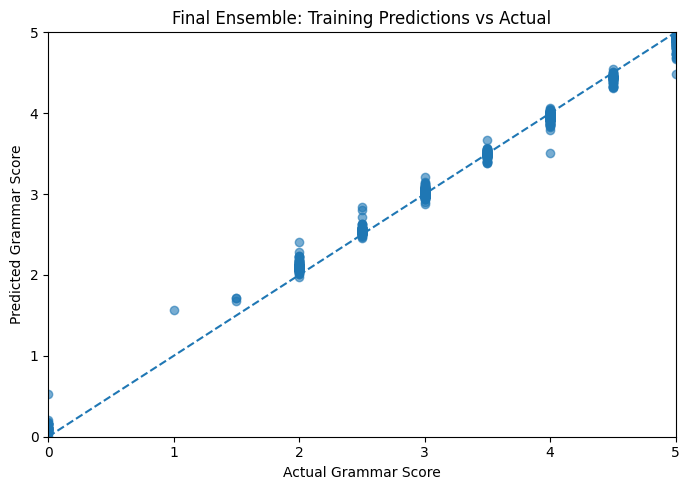

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(
    y,
    train_final_pred,
    alpha=0.6
)

plt.plot(
    [0, 5],
    [0, 5],
    linestyle="--"
)

plt.xlabel("Actual Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Final Ensemble: Training Predictions vs Actual")

plt.xlim(0, 5)
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

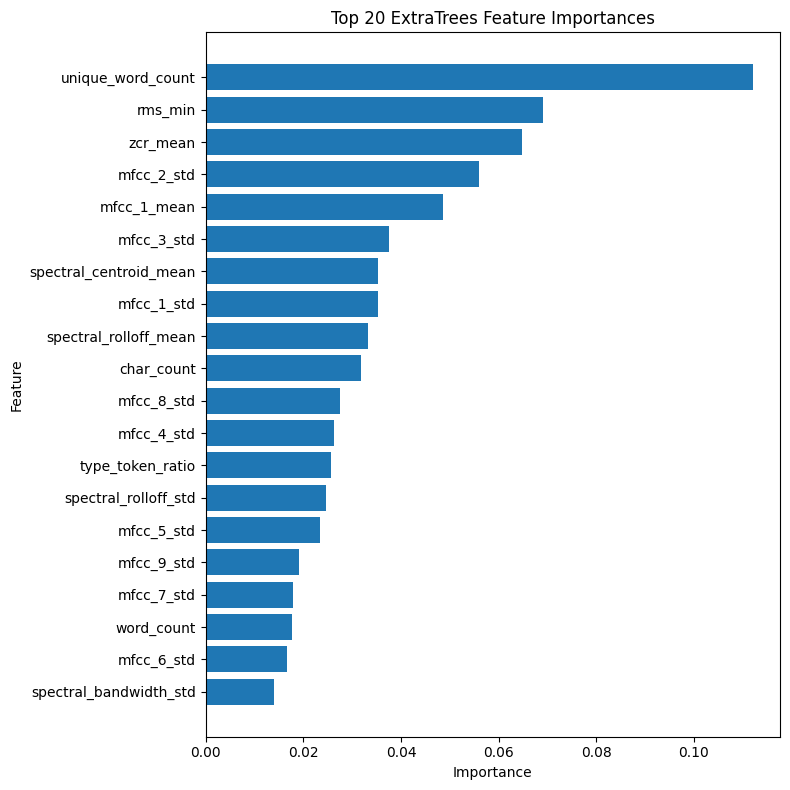

In [21]:
# ============================================================
# EXTRA TREES FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(8, 8))

top_features = (
    importance_df
    .head(20)
    .sort_values("importance")
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 ExtraTrees Feature Importances")

plt.tight_layout()
plt.show()

In [26]:
submission_path = "/kaggle/working/submission.csv"

In [29]:
import os

print("Files in /kaggle/working:")
for f in os.listdir("/kaggle/working"):
    print(f)

Files in /kaggle/working:
.virtual_documents
submission_68ET_32Ridge.csv


In [30]:
import shutil

shutil.copy(
    "/kaggle/working/submission_68ET_32Ridge.csv",
    "/kaggle/working/submission.csv"
)

print("Created:", "/kaggle/working/submission.csv")

Created: /kaggle/working/submission.csv


In [31]:
import pandas as pd

df = pd.read_csv("/kaggle/working/submission.csv")

print(df.head())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

        filename     label
0  audio_128.wav  2.679137
1  audio_156.wav  3.904733
2   audio_19.wav  3.819336
3  audio_108.wav  2.458226
4  audio_206.wav  2.886218
Shape: (216, 2)
Columns: ['filename', 'label']
